### Question 5.2

In [1]:
import numpy as np

inputed = input('Input the _name_ (no extension) of the file you wish to open:')
try:
    file = np.loadtxt(inputed+'.txt')
    x = file[:,0]
    y = file[:,1]

    print(f"The x values are {', '.join(map(str,x))}")
    print(f"\tx_mean = {np.mean(x)}")
    print(f"\tx_min = {np.min(x)}")
    print(f"\tx_max = {np.max(x)}")

    print(f"The y values are {', '.join(map(str,y))}")
    print(f"\ty_mean = {np.mean(y)}")
    print(f"\ty_min = {np.min(y)}")
    print(f"\ty_max = {np.max(y)}")

    y2 = (y - np.median(y))**2
    print(f"y2 = (y - y_median)**2 : {', '.join(map(str,y2))}")
    
except:
    print("An unexpected error occured whilst opening the file.")

Input the _name_ (no extension) of the file you wish to open: file


The x values are 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0
	x_mean = 5.5
	x_min = 1.0
	x_max = 10.0
The y values are 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0, 100.0
	y_mean = 55.0
	y_min = 10.0
	y_max = 100.0
y2 = (y - y_median)**2 : 2025.0, 1225.0, 625.0, 225.0, 25.0, 25.0, 225.0, 625.0, 1225.0, 2025.0


### Question 5.6

In [2]:
import numpy as np
a = np.array([1, 2, 3]) # 1 dimensional array
b = np.array([4, 5, 6]) # 1 dimensional array
new_array = np.concatenate((a, b))
print(new_array)
print(np.shape(new_array))

[1 2 3 4 5 6]
(6,)


In [3]:
import numpy as np

a = np.array([[1, 2], [3, 4]]) # 2 dimensional array
b = np.array([[5, 6], [7, 8]]) # 2 dimensional array

print(np.concatenate((a, b)))
print(np.concatenate((a, b), axis=0))
print(np.concatenate((a, b), axis=1))

[[1 2]
 [3 4]
 [5 6]
 [7 8]]
[[1 2]
 [3 4]
 [5 6]
 [7 8]]
[[1 2 5 6]
 [3 4 7 8]]


### Question 5.9

/tmp/ipykernel_967429/3403433297.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = io.imread('m101BW.jpg')


[[24 24 23 ... 20 20 19]
 [23 22 25 ... 20 20 19]
 [21 21 23 ... 19 20 19]
 ...
 [32 27 22 ... 42 32 14]
 [23 22 20 ... 43 16 18]
 [22 22 20 ... 24 18 17]]


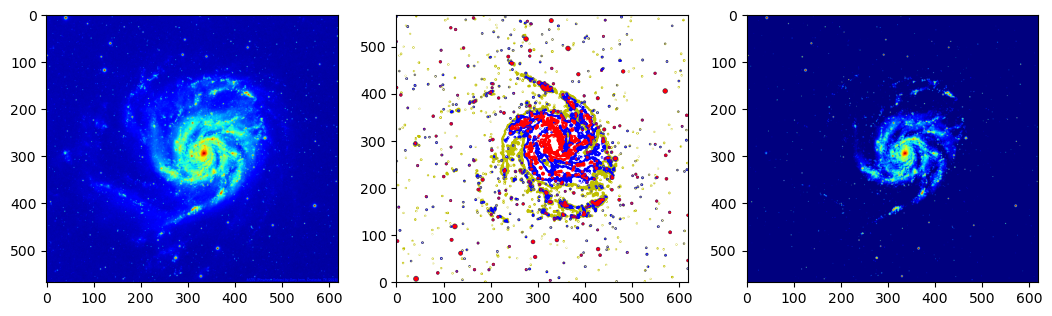

In [4]:
import imageio as io
import matplotlib.pyplot as plt

main = plt.figure(figsize = [12.8, 9.6])

img = io.imread('m101BW.jpg')
print(img)
plot1 = main.add_subplot(1,3,1)

plot1.imshow(img, cmap='jet')
plot2 = main.add_subplot(1,3,2)
plot2.contour(img,levels=np.percentile(img,[90,95,99]),colors = ['y','b','r'])
plt.gca().set_aspect('equal')

bound = np.percentile(img,90)
filtered = np.where(img > bound, img, bound)
plot3 = main.add_subplot(1,3,3)
plot3.imshow(filtered, cmap='jet')
plt.show()

### Question 5.10

The z profile is [0.00482 0.00666 0.00705 0.00889 0.01269 0.02012 0.02789 0.03712 0.03985
 0.04617 0.0606  0.04935 0.02734 0.01746 0.0149  0.0247  0.03478 0.03472
 0.03174 0.02931 0.02995 0.02909 0.02687 0.0247  0.02483 0.02504 0.02486
 0.0228  0.01888 0.01625 0.01589 0.01473 0.01294 0.01236 0.01144 0.01118
 0.01038 0.00848 0.00751 0.0072 ]

The statistics for the z-profile:
	Min: 0.00482
	Max: 0.0606
	Sum: 0.89154
	Mean: 0.012699434544498428
	Standard deviation: 0.0222885


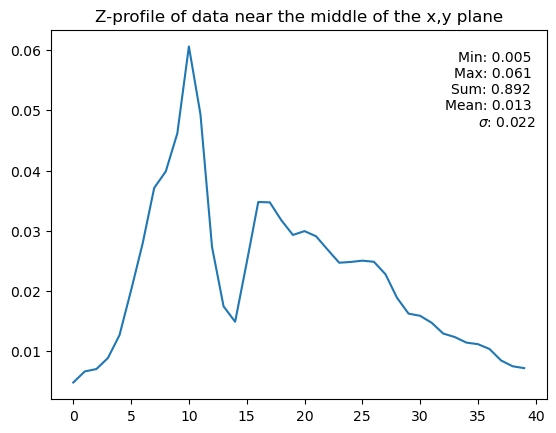

In [5]:
import numpy as np
import matplotlib.pyplot as plt
file = np.loadtxt('ngc6946.txt').reshape(40,50,70)

zprof = file[:,25,35]
print(f"The z profile is {zprof}\n")


mn = np.min(zprof)
mx = np.max(zprof)
s = np.sum(zprof)
st = np.mean(zprof)
mean = np.std(zprof)

print('The statistics for the z-profile:')
print(f'\tMin: {mn}')
print(f'\tMax: {mx}')
print(f'\tSum: {s}')
print(f'\tMean: {mean}')
print(f'\tStandard deviation: {st}')

plt.plot(zprof)
stats = f'Min: {mn:.3f} \nMax: {mx:.3f} \nSum: {s:.3f} \nMean: {mean:.3f} \n$\sigma$: {st:.3f}'
plt.text(40,0.06,stats, horizontalalignment='right',verticalalignment='top')
plt.title("Z-profile of data near the middle of the x,y plane")
plt.show()

### Question 5.11

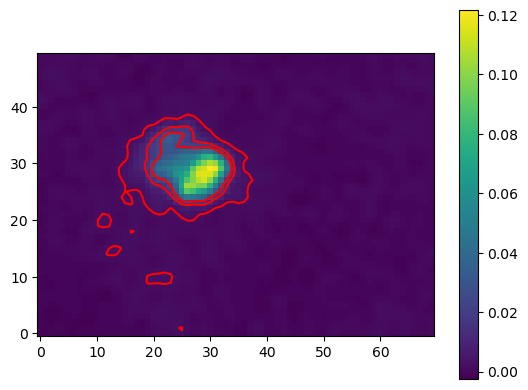

In [6]:
extracted = file[0,::]
plt.imshow(extracted, origin = 'lower')
plt.colorbar()

mean = np.mean(extracted)
std = np.std(extracted)
plt.contour(extracted,levels=[mean, mean+std, mean+2*std],colors = 'r')
plt.show()

### Question 5.12

In [7]:
class Galaxy:    
    """Class for redshift calculation of galaxies"""  
        
    caH_0 = 3968.5      # Calcium H line in rest frame
    from scipy.constants import c
    
    def __init__(self, name, calciumHline=caH_0):
        self.name = name
        self.caH = calciumHline
    def redshift(self):        
        z = (self.caH - self.caH_0)/self.caH
        return z
    def velocity(self):
        v  = self.redshift()*self.c/1000
        return v
    
gal2 = Galaxy("NGC1832", 3994.7)
print(f'Example from the original notebook: {gal2.name} galaxy\'s relative radial velocity is {gal2.velocity():.3f} km/s.')

Example from the original notebook: NGC1832 galaxy's relative radial velocity is 1966.246 km/s.


### Question 5.12

In [8]:
from matplotlib.patches import Ellipse

class AstroEllipse(Ellipse):
    
   def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
      # We use the (sort of) astronomical angle where 'angle' defines)
      # the position angle of the major axis of a ring projected onto the sky
      # (i.e. an ellipse). This is an angle taken in anti-clockwise direction between
      # the north direction on the sky and the major axis of the receding half of the
      # galaxy (Rots 1975, astron, astrophys 45, 43).
      # Here we assume (!) north is in the positive Y direction.
      # If not, you need to correct the angle for the rotation of the image.
      # Parameter 'position_angle' enters in degrees
      assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous
      XY = (xc, yc)                  # MPL requires center as a tuple
      angle_mpl = position_angle     # Angle for MatPlotLib's ellipse patch
      height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
      width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse
      super().__init__(XY, width, height, angle=angle_mpl, **args)

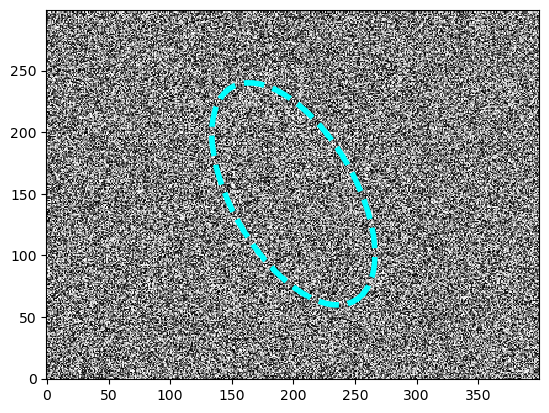

In [9]:
import numpy as np
from matplotlib.pyplot import figure, show

Nx = 400
Ny = 300
data = np.random.random((Ny,Nx))

fig = figure()
frame = fig.add_subplot(1,1,1)
plt.imshow(data,interpolation='none', origin="lower", cmap='gray')



"""  semi-major axis: 100 pixels

    semi-minor axis: 50 pixels

    position angle: 30.0 deg."""

elip = AstroEllipse(Nx/2,Ny/2,100,50,30, fill=False,color = 'cyan',linewidth = 4,linestyle = '--')
frame.add_patch(elip)

show()